# KNN (K-Nearest Neighbors) Algorithm with Regression - House Energy Dataset

In [35]:
import pandas as pd # Veri işleme ve analiz için kullanılan kütüphane.
import seaborn as sns # Veri görselleştirme için kullanılan kütüphane.
import matplotlib.pyplot as plt # Grafik çizimi için kullanılan kütüphane.

from sklearn.model_selection import train_test_split # Veri setini eğitim ve test olarak bölmek için kullanılan fonksiyon.
from sklearn.preprocessing import StandardScaler # Veriyi standartlaştırmak için kullanılan sınıf.
from sklearn.neighbors import KNeighborsRegressor # KNN regresyon modeli için kullanılan sınıf.
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # Model performansını değerlendirmek için kullanılan metrikler.

In [36]:
df = pd.read_csv("../../data/HouseEnergy.csv") # Veri setini CSV dosyasından yükler. 
# Bu veri seti, evlerin enerji tüketimini etkileyen özellikleri ve hedef değişkeni içermektedir.

# Display the first few rows of the dataset
df.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [37]:
# avg_indoor_temp_change -> Change in indoor temperature over the past 24h (°C)
# outdoor_humidity_level -> Relative outdoor humidity (%)
# daily_energy_consumption_kwh -> Energy usage (in kWh) for the household over one day

In [38]:
df.info() # Veri setindeki sütunların veri tiplerini ve eksik değerleri kontrol eder.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [39]:
df.describe() # Veri setindeki sayısal sütunların temel istatistiklerini gösterir. 
# Bu, sütunların ortalama, standart sapma, minimum, maksimum ve çeyrek değerlerini içerir.

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


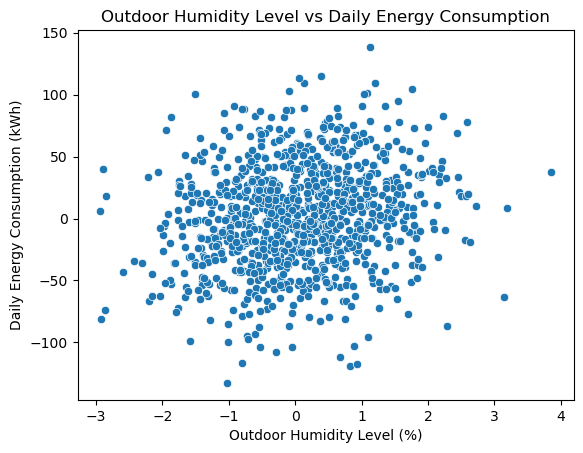

In [40]:
# Scatter plot görselleştirmesi, iki sayısal değişken arasındaki ilişkiyi göstermek için kullanılır.
# Scatter plot, özellikle regresyon analizinde, bağımsız değişkenler ile bağımlı değişken arasındaki ilişkiyi görselleştirmek için sıklıkla kullanılır.
# Noktalar, her bir gözlemi temsil eder ve x ve y eksenlerinde ilgili değişkenlerin değerlerini gösterir. 
# Scatter plot, her bir veri noktasını temsil eden bir nokta ile gösterilir. Noktaların dağılımı, iki değişken arasındaki ilişki hakkında bilgi verir.
# Renkler veya şekiller, ek kategorik değişkenleri temsil etmek için kullanılabilir, bu da verilerdeki desenleri ve ilişkileri daha kolay tanımlamaya yardımcı olur.
# Örneğin, noktaların belirli bir eğilim göstermesi (örneğin, artan bir eğilim) iki değişken arasında pozitif bir ilişki olduğunu gösterebilir. Noktaların rastgele dağılması ise iki değişken arasında güçlü bir ilişki olmadığını gösterebilir.

# Bu durumda, outdoor_humidity_level (yatay eksen) ve daily_energy_consumption_kwh (dikey eksen) arasındaki ilişkiyi görselleştirir.
sns.scatterplot(x=df['outdoor_humidity_level'],y=df['daily_energy_consumption_kwh'])
plt.title("Outdoor Humidity Level vs Daily Energy Consumption")
plt.xlabel("Outdoor Humidity Level (%)")
plt.ylabel("Daily Energy Consumption (kWh)")
plt.show()

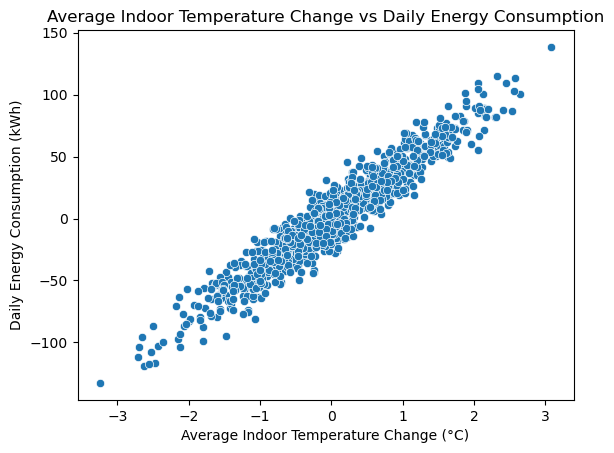

In [41]:
# avg_indoor_temp_change (yatay eksen) ve daily_energy_consumption_kwh (dikey eksen) arasındaki ilişkiyi görselleştirir.
# avg_indoor_temp_change, iç mekan sıcaklığındaki değişimi temsil eder ve bu değişim, enerji tüketimini etkileyebilir.
sns.scatterplot(x=df['avg_indoor_temp_change'],y=df['daily_energy_consumption_kwh'])
plt.title("Average Indoor Temperature Change vs Daily Energy Consumption")
plt.xlabel("Average Indoor Temperature Change (°C)")
plt.ylabel("Daily Energy Consumption (kWh)")
plt.show()

In [42]:
# Korelasyon matrisi, her bir sayısal sütun çifti arasındaki doğrusal ilişkiyi gösterir.
# Korelasyon katsayısı -1 ile 1 arasında değişir. 
# 1'e yakın bir değer, güçlü pozitif bir ilişki olduğunu gösterirken, -1'e yakın bir değer güçlü negatif bir ilişki olduğunu gösterir. 
# 0'a yakın bir değer ise iki değişken arasında güçlü bir doğrusal ilişki olmadığını gösterir.

# Korelasyon matrisi, hangi özelliklerin hedef değişkenle daha güçlü bir ilişkiye sahip olduğunu belirlemek için kullanılabilir. Bu, modelleme sürecinde hangi özelliklerin daha önemli olduğunu anlamaya yardımcı olabilir.
# Korelasyon matrisi, özellikle regresyon analizinde, bağımsız değişkenler arasındaki ilişkileri ve bağımsız değişkenlerin hedef değişkenle olan ilişkisini değerlendirmek için önemli bir araçtır.
df.corr() # Veri setindeki sayısal sütunlar arasındaki korelasyon matrisini hesaplar.

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


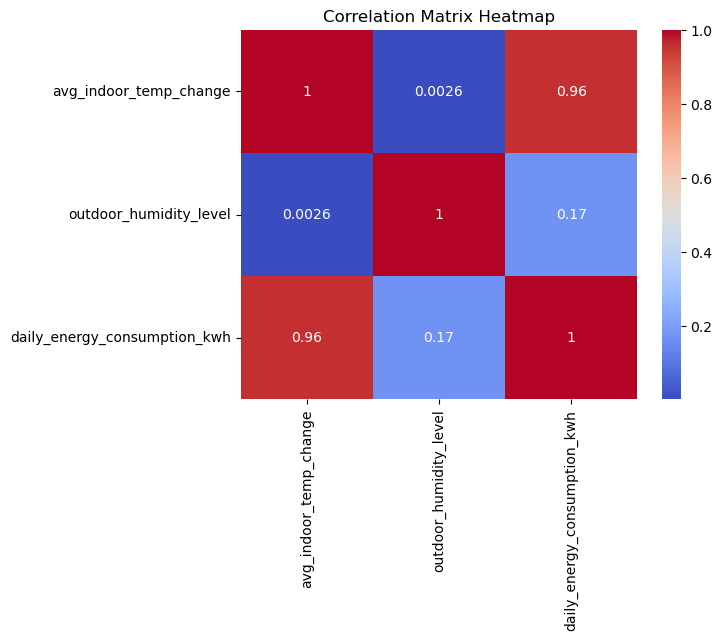

In [43]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') # Korelasyon matrisini ısı haritası olarak görselleştirir.
plt.title("Correlation Matrix Heatmap")
plt.show()

In [44]:
df.corr()['daily_energy_consumption_kwh'].sort_values(ascending=False) # Hedef değişkenle diğer değişkenler arasındaki korelasyonu sıralar.

daily_energy_consumption_kwh    1.000000
avg_indoor_temp_change          0.956682
outdoor_humidity_level          0.169557
Name: daily_energy_consumption_kwh, dtype: float64

In [45]:
X=df.drop('daily_energy_consumption_kwh',axis=1) # Hedef değişken olan 'daily_energy_consumption_kwh' sütununu bağımsız değişkenlerden ayırır ve X değişkenine atar.
y=df['daily_energy_consumption_kwh'] # Hedef değişken olan 'daily_energy_consumption_kwh' sütununu y değişkenine atar.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15) # Veri setini eğitim ve test olarak böler. Test seti, veri setinin %30'u kadar olacak şekilde ayrılır. random_state parametresi, bölme işleminin tekrarlanabilir olmasını sağlar.

In [47]:
# KNN algoritması, özellikle özellikler farklı ölçeklerde olduğunda performansını artırmak için veri standartlaştırma gerektirir.
# Veriyi standartlaştırmak, KNN algoritmasının performansını artırabilir çünkü KNN, veri noktaları arasındaki mesafeleri kullanarak tahminler yapar. Eğer özellikler farklı ölçeklerdeyse, bazı özellikler diğerlerine göre daha fazla ağırlık kazanabilir ve bu da modelin performansını olumsuz etkileyebilir.
# Bu nedenle, KNN algoritması kullanmadan önce veriyi standartlaştırmak genellikle iyi bir uygulamadır.

# StandardScaler kullanarak veriyi standartlaştırır. 
# StandardScaler, veriyi ortalaması 0 ve standart sapması 1 olacak şekilde dönüştürür. 
# Bu, KNN algoritmasının farklı özellikler arasındaki mesafeleri daha doğru bir şekilde hesaplamasına yardımcı olur.

# fit_transform, eğitim verisi üzerinde standartlaştırma işlemini gerçekleştirir ve aynı zamanda öğrenilen parametreleri (ortalama ve standart sapma) kaydeder. 
# transform ise test verisi üzerinde aynı parametreleri kullanarak standartlaştırma işlemini gerçekleştirir.

# Eğitim verisi üzerinde fit_transform kullanmak, modelin eğitim verisine özgü parametreleri öğrenmesini sağlar. 
# Test verisi üzerinde transform kullanmak ise modelin test verisine özgü parametreler öğrenmesini engeller ve böylece modelin genelleme yeteneğini değerlendirirken daha doğru sonuçlar elde edilmesini sağlar.
scaler = StandardScaler() # StandardScaler sınıfından bir nesne oluşturur.

X_train_scaled = scaler.fit_transform(X_train) # Eğitim verisi üzerinde standartlaştırma işlemini gerçekleştirir ve aynı zamanda öğrenilen parametreleri (ortalama ve standart sapma) kaydeder.
X_test_scaled = scaler.transform(X_test) # Test verisi üzerinde aynı parametreleri kullanarak standartlaştırma işlemini gerçekleştirir. Bu, modelin test verisine özgü parametreler öğrenmesini engeller ve böylece modelin genelleme yeteneğini değerlendirirken daha doğru sonuçlar elde edilmesini sağlar.

In [48]:
# KNN regresyon modelini oluşturur ve eğitim verisi üzerinde eğitir.

# KNN algoritması, tahmin yaparken en yakın komşuların hedef değişken değerlerini kullanır. Bu nedenle, n_neighbors parametresi, modelin tahmin yaparken kaç komşuyu dikkate alacağını belirler.
# Bu değer, modelin esnekliğini ve genelleme yeteneğini etkiler. 
# Genellikle, n_neighbors değeri küçük olduğunda model daha esnek olur ve eğitim verisine daha iyi uyum sağlar, ancak aşırı uyum (overfitting) riski artar. 
# Büyük bir n_neighbors değeri ise modelin daha genel hale gelmesine yardımcı olabilir, ancak aşırı genelleme (underfitting) riski artar. 
# Genellikle, n_neighbors değeri 3 ile 10 arasında seçilir (default değeri 5'tir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# weights parametresi, KNN algoritmasının komşuların hedef değişken değerlerini nasıl ağırlıklandıracağını belirler.
# Genellikle, weights parametresi 'uniform' veya 'distance' olarak seçilir (default değeri 'uniform'dur), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.
# 'uniform' seçeneği, tüm komşulara eşit ağırlık verir. Bu, modelin tahmin yaparken tüm komşuların hedef değişken değerlerini aynı şekilde dikkate alacağı anlamına gelir.
# 'distance' seçeneği, daha yakın komşulara daha fazla ağırlık verir. Bu, modelin tahmin yaparken daha yakın komşuların hedef değişken değerlerini daha fazla dikkate alacağı anlamına gelir.
# 'distance' seçeneği, özellikle komşuların hedef değişken değerlerinin birbirinden farklı olduğu durumlarda, modelin tahmin performansını artırabilir.

# leaf_size parametresi, KNN algoritmasının kullandığı veri yapısında (örneğin, KD-tree veya Ball-tree) yaprak düğümünde bulunacak maksimum örnek sayısını belirler.
# Bu parametre, KNN algoritmasının performansını etkileyebilir.
# Daha küçük bir leaf_size değeri, daha fazla yaprak düğümü oluşturulmasına neden olur, bu da daha hızlı sorgu süreleri sağlayabilir ancak daha fazla bellek kullanabilir. 
# Daha büyük bir leaf_size değeri ise daha az yaprak düğümü oluşturulmasına neden olur, bu da daha yavaş sorgu süreleri sağlayabilir ancak daha az bellek kullanabilir. 
# Genellikle, leaf_size değeri 20 ile 40 arasında seçilir (default değeri 30'dur), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# p parametresi, KNN algoritmasının kullandığı mesafe metriğini belirler.
# p=1, Manhattan mesafesini kullanır. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin mutlak farklarının toplamı olarak hesaplar.
# p=2, Euclidean mesafesini kullanır. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin farklarının karelerinin toplamının karekökü olarak hesaplar.
# p=3, Minkowski mesafesini kullanır. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin farklarının p'inci kuvvetlerinin toplamının p'inci kökü olarak hesaplar.
# Genellikle, p parametresi 1 veya 2 olarak seçilir (default değeri 2'dir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# metric parametresi, KNN algoritmasının kullandığı mesafe metriğini belirler. Yani KNN algoritmasının hangi mesafe metriğini kullanarak komşuları bulacağını belirtir. 
# 'minkowski' seçeneği, p parametresine bağlı olarak farklı mesafe metriklerini kullanır. p=1 için Manhattan mesafesi, p=2 için Euclidean mesafesi kullanılır.
# 'euclidean' seçeneği, KNN algoritmasının her zaman Euclidean mesafesini kullanmasını sağlar. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin farklarının karelerinin toplamının karekökü olarak hesaplar.
# 'manhattan' seçeneği, KNN algoritmasının her zaman Manhattan mesafesini kullanmasını sağlar. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin mutlak farklarının toplamı olarak hesaplar.
# 'chebyshev' seçeneği, KNN algoritmasının her zaman Chebyshev mesafesini kullanmasını sağlar. Bu, iki nokta arasasındaki mesafeyi, her bir özelliğin farklarının maksimumu olarak hesaplar.
# 'haversine' seçeneği, KNN algoritmasının her zaman Haversine mesafesini kullanmasını sağlar. Bu, iki nokta arasasındaki mesafeyi, küresel koordinatlar (enlem ve boylam) kullanarak hesaplar.
# 'mahalanobis' seçeneği, KNN algoritmasının her zaman Mahalanobis mesafesini kullanmasını sağlar. Bu, iki nokta arasasındaki mesafeyi, verinin kovaryans matrisini kullanarak hesaplar.
# Genellikle, metric parametresi 'minkowski' olarak seçilir (default değeri 'minkowski'dir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# n_jobs parametresi, KNN algoritmasının komşuları bulmak için kaç işlemci çekirdeği kullanacağını belirler.
# n_jobs=-1 olarak ayarlandığında, KNN algoritması tüm kullanılabilir işlemci çekirdeklerini kullanır. Bu, büyük veri setlerinde KNN algoritmasının performansını artırabilir, ancak sistem kaynaklarını yoğun bir şekilde kullanabilir.
# n_jobs=1 olarak ayarlandığında, KNN algoritması tek bir işlemci çekirdeği kullanır. Bu, küçük veri setlerinde yeterli olabilir ve sistem kaynaklarını daha az kullanır.
# Genellikle, n_jobs parametresi -1 olarak seçilir (default değeri 1'dir), ancak en iyi performansı sağlamak için veri setinin büyüklüğüne ve sistem kaynaklarına bağlı olarak optimize edilebilir.

# algorithm parametresi, KNN algoritmasının hangi yöntemi kullanarak en yakın komşuları bulacağını belirtir.
# 'auto' seçeneği, verinin yapısına göre en uygun yöntemi otomatik olarak seçer. Bu, KNN algoritmasının farklı veri setleri için en iyi performansı sağlamasına yardımcı olabilir.
# ball_tree, KD_tree ve brute seçenekleri de algorithm parametresi için kullanılabilir. 
# Ball_tree ve KD_tree, KNN algoritmasının komşuları bulmak için farklı veri yapıları kullanmasını sağlar. 
# Ball_tree, yüksek boyutlu veri setlerinde daha iyi performans gösterebilirken, KD_tree düşük boyutlu veri setlerinde daha iyi performans gösterebilir.
# Brute seçeneği ise KNN algoritmasının tüm veri noktalarını tarayarak en yakın komşuları bulmasını sağlar.
# Genellikle, algorithm parametresi 'auto' olarak seçilir (default değeri 'auto'dur), ancak en iyi performansı sağlamak için veri setinin yapısına bağlı olarak optimize edilebilir.

# n_neighbors=5, algoritmanın tahmin yaparken dikkate alacağı en yakın komşu sayısını belirtir.
# algorithm='auto', KNN algoritmasının hangi yöntemi kullanarak en yakın komşuları bulacağını belirtir. 'auto' seçeneği, verinin yapısına göre en uygun yöntemi otomatik olarak seçer.
regressor=KNeighborsRegressor(n_neighbors=5,algorithm='auto')

# KNN algoritması, tahmin yaparken en yakın komşuların hedef değişken değerlerini kullanır. 
# Bu nedenle, KNN regresyon modelini eğitirken, modelin eğitim verisi üzerinde öğrenmesi gereken parametreler yoktur. Model, tahmin yaparken doğrudan eğitim verisindeki komşuları kullanır.
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [49]:
y_pred=regressor.predict(X_test_scaled)

In [50]:
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))

r2 score:  0.9152685146562609
mean absolute error:  9.42143518926242
mean squared error:  140.40201685069158


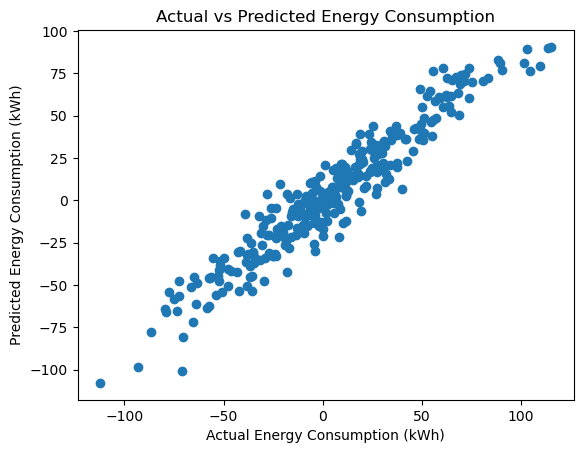

In [51]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [52]:
# you can again test with different k values

In [53]:
regressor=KNeighborsRegressor(n_neighbors=7,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=7)

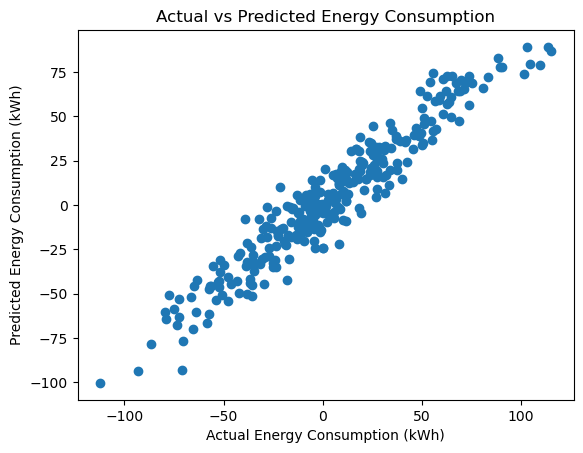

r2 score:  0.9164863388635838
mean absolute error:  9.331428506491209
mean squared error:  138.3840541750219


In [54]:
y_pred=regressor.predict(X_test_scaled)

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))

In [55]:
regressor=KNeighborsRegressor(n_neighbors=25,algorithm='auto') # if you exaggerate k values, your metrics will decrease
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=25)

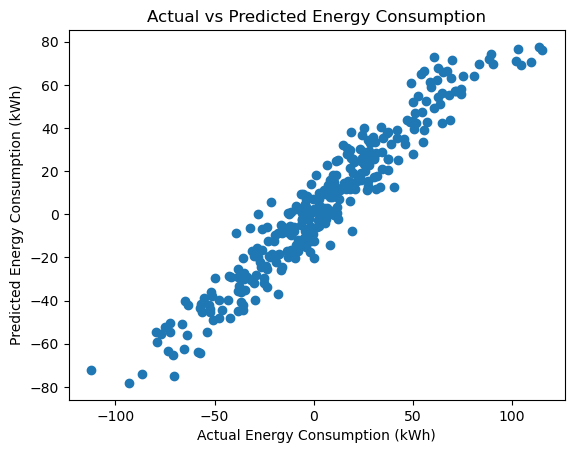

r2 score:  0.9118719343331324
mean absolute error:  9.42127621485675
mean squared error:  146.0302284396658


In [56]:
y_pred=regressor.predict(X_test_scaled)

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))